#📌 Extracción
En esta etapa, nos conectamos a la fuente de datos (GitHub) para obtener el archivo JSON y cargarlo en un entorno de Pandas.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import requests

In [2]:
# URL de la API (GitHub Raw)
url = 'https://raw.githubusercontent.com/ingridcristh/challenge2-data-science-LATAM/main/TelecomX_Data.json'

In [4]:
# Extracción de datos
response = requests.get(url)
data_json = response.json()
data_json

[{'customerID': '0002-ORFBO',
  'Churn': 'No',
  'customer': {'gender': 'Female',
   'SeniorCitizen': 0,
   'Partner': 'Yes',
   'Dependents': 'Yes',
   'tenure': 9},
  'phone': {'PhoneService': 'Yes', 'MultipleLines': 'No'},
  'internet': {'InternetService': 'DSL',
   'OnlineSecurity': 'No',
   'OnlineBackup': 'Yes',
   'DeviceProtection': 'No',
   'TechSupport': 'Yes',
   'StreamingTV': 'Yes',
   'StreamingMovies': 'No'},
  'account': {'Contract': 'One year',
   'PaperlessBilling': 'Yes',
   'PaymentMethod': 'Mailed check',
   'Charges': {'Monthly': 65.6, 'Total': '593.3'}}},
 {'customerID': '0003-MKNFE',
  'Churn': 'No',
  'customer': {'gender': 'Male',
   'SeniorCitizen': 0,
   'Partner': 'No',
   'Dependents': 'No',
   'tenure': 9},
  'phone': {'PhoneService': 'Yes', 'MultipleLines': 'Yes'},
  'internet': {'InternetService': 'DSL',
   'OnlineSecurity': 'No',
   'OnlineBackup': 'No',
   'DeviceProtection': 'No',
   'TechSupport': 'No',
   'StreamingTV': 'No',
   'StreamingMovies': 

In [5]:
# Conversión a DataFrame
df = pd.json_normalize(data_json)
df.head()

,customerID,Churn,customer.gender,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,phone.MultipleLines,internet.InternetService,...,internet.OnlineBackup,internet.DeviceProtection,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,account.Contract,account.PaperlessBilling,account.PaymentMethod,account.Charges.Monthly,account.Charges.Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.4


#🔧 Transformación
Aquí realizamos la limpieza, corregimos inconsistencias y preparamos las variables para el análisis.

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customerID                 7267 non-null   object 
 1   Churn                      7267 non-null   object 
 2   customer.gender            7267 non-null   object 
 3   customer.SeniorCitizen     7267 non-null   int64  
 4   customer.Partner           7267 non-null   object 
 5   customer.Dependents        7267 non-null   object 
 6   customer.tenure            7267 non-null   int64  
 7   phone.PhoneService         7267 non-null   object 
 8   phone.MultipleLines        7267 non-null   object 
 9   internet.InternetService   7267 non-null   object 
 10  internet.OnlineSecurity    7267 non-null   object 
 11  internet.OnlineBackup      7267 non-null   object 
 12  internet.DeviceProtection  7267 non-null   object 
 13  internet.TechSupport       7267 non-null   objec

In [7]:
# 2. Manejo de inconsistencias en 'Charges.Total'
# Observamos que Charges.Total es objeto porque tiene espacios en blanco
df['account.Charges.Total'] = pd.to_numeric(df['account.Charges.Total'], errors='coerce')
df['account.Charges.Total'] = df['account.Charges.Total'].fillna(0)

In [8]:
# 3. Creación de columna 'Cuentas_Diarias' (Opcional recomendado)
df['Cuentas_Diarias'] = (df['account.Charges.Monthly'] / 30).round(2)

In [9]:
# 4. Estandarización y Traducción (Opcional recomendado)
# Convertir Churn a binario para facilitar cálculos matemáticos
mapeo_binario = {'Yes': 1, 'No': 0}
df['Churn_Binario'] = df['Churn'].map(mapeo_binario)

In [10]:
# Renombrar columnas para facilitar acceso (quitando puntos de la normalización)
df.columns = [col.replace('.', '_') for col in df.columns]

print("Inconsistencias corregidas y nuevas columnas creadas.")

Inconsistencias corregidas y nuevas columnas creadas.


#📊 Carga y análisis
Analizamos el comportamiento de los datos para encontrar patrones que expliquen por qué los clientes se van (Churn).

### Análisis Descriptivo

In [11]:
# Estadísticas de variables numéricas
print(df[['customer_tenure', 'account_Charges_Monthly', 'account_Charges_Total', 'Cuentas_Diarias']].describe())

       customer_tenure  account_Charges_Monthly  account_Charges_Total  \
count      7267.000000              7267.000000            7267.000000   
mean         32.346498                64.720098            2277.182035   
std          24.571773                30.129572            2268.648587   
min           0.000000                18.250000               0.000000   
25%           9.000000                35.425000             396.200000   
50%          29.000000                70.300000            1389.200000   
75%          55.000000                89.875000            3778.525000   
max          72.000000               118.750000            8684.800000   

       Cuentas_Diarias  
count      7267.000000  
mean          2.157292  
std           1.004407  
min           0.610000  
25%           1.180000  
50%           2.340000  
75%           2.995000  
max           3.960000  


### Visualización de Evasión (Churn)

/tmp/ipykernel_226/3531993378.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Churn', data=df, palette='viridis')


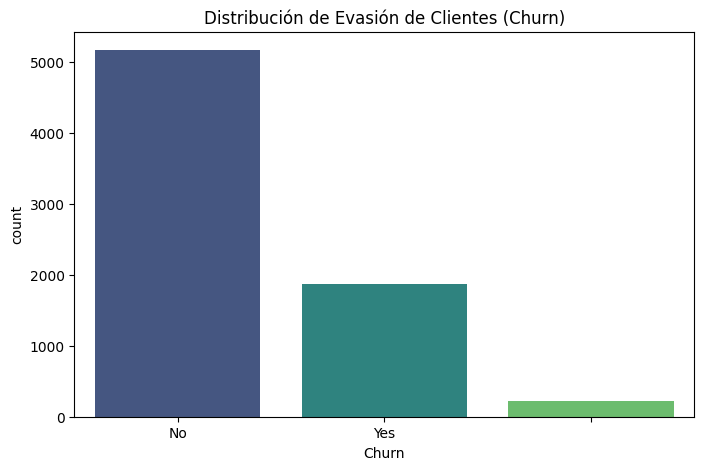

Churn
No     71.198569
Yes    25.719004
        3.082427
Name: proportion, dtype: float64


In [12]:
plt.figure(figsize=(8, 5))
sns.countplot(x='Churn', data=df, palette='viridis')
plt.title('Distribución de Evasión de Clientes (Churn)')
plt.show()

# Proporción exacta
print(df['Churn'].value_counts(normalize=True) * 100)

### Evasión por Variables Categóricas y Numéricas

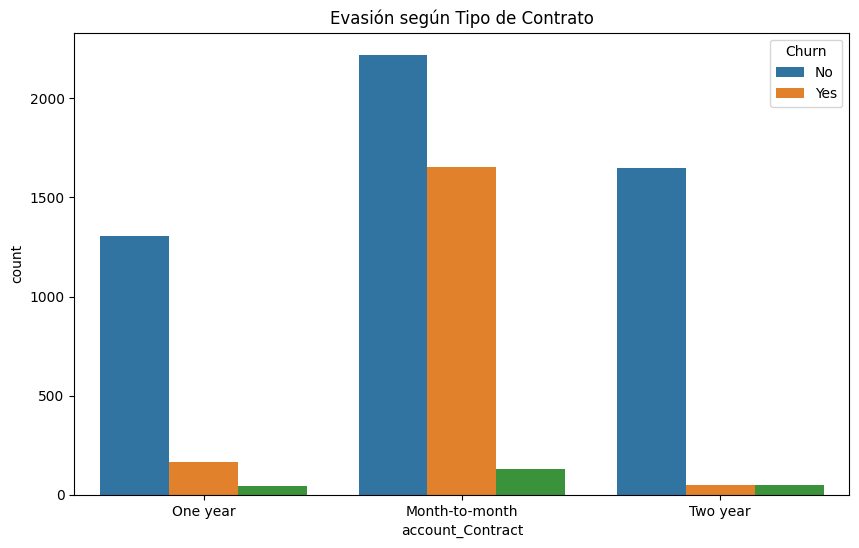

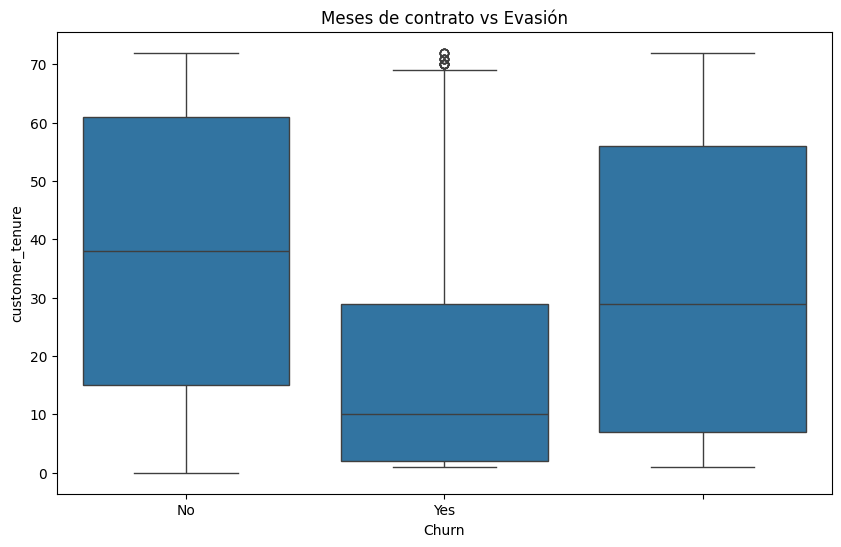

In [13]:
# ¿Influye el tipo de contrato en el Churn?
plt.figure(figsize=(10, 6))
sns.countplot(x='account_Contract', hue='Churn', data=df)
plt.title('Evasión según Tipo de Contrato')
plt.show()

# ¿El tiempo de permanencia (tenure) afecta la evasión?
plt.figure(figsize=(10, 6))
sns.boxplot(x='Churn', y='customer_tenure', data=df)
plt.title('Meses de contrato vs Evasión')
plt.show()

# Analisis de correlacion

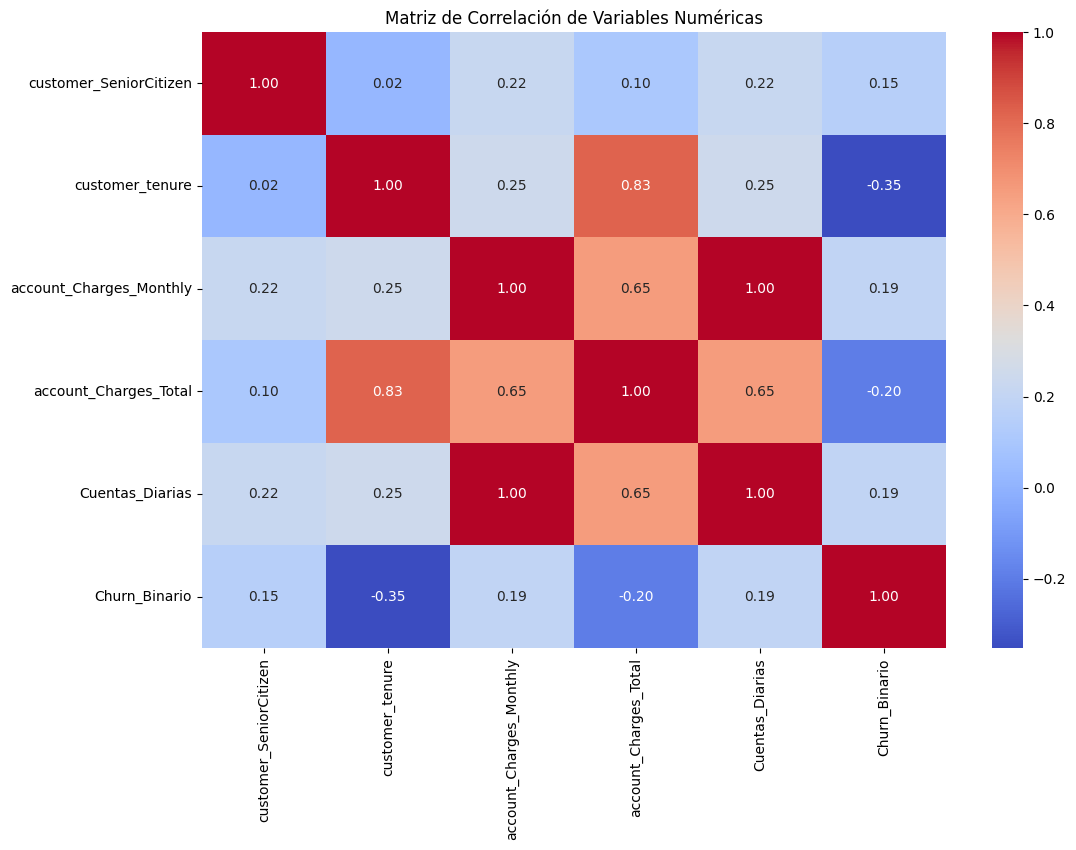

In [14]:
plt.figure(figsize=(12, 8))
corr = df.select_dtypes(include=[np.number]).corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Matriz de Correlación de Variables Numéricas')
plt.show()

#📄Informe final

🔹 **Introducción**
El proyecto Telecom X busca identificar las causas principales del "Churn" o evasión de clientes. La pérdida de usuarios impacta directamente en los ingresos y la estabilidad de la empresa. Este análisis provee la base para que el equipo de Data Science desarrolle modelos predictivos.

🔹 **Limpieza y Tratamiento de Datos**
*   Normalización: Los datos JSON anidados se aplanaron para su uso en Pandas.
*   Corrección de Tipos: Se transformó Charges_Total de texto a numérico, gestionando valores nulos.
*   Ingeniería de Características: Se creó la variable Cuentas_Diarias y se binarizó el Churn para análisis estadístico.

🔹 **Conclusiones e Insights**
1.   Contratos a corto plazo: Los clientes con contratos de "Mes a mes" presentan la tasa de evasión más alta.
2.   Permanencia (Tenure): Existe una relación inversa; a menor tiempo en la empresa, mayor es la probabilidad de cancelar el servicio. Los primeros 6-12 meses son críticos.
3.   Cargos Mensuales: Los clientes que cancelan tienden a tener cargos mensuales más altos en promedio que los que permanecen.

🔹 **Recomendaciones**
*   Incentivos de Lealtad: Ofrecer descuentos o beneficios a los clientes que migren de contratos mensuales a contratos de uno o dos años.

*   Programa de Bienvenida: Reforzar el soporte técnico y la atención durante los primeros 6 meses de contrato para reducir la deserción temprana.

*   Revisión de Precios: Analizar si el costo de los servicios de fibra óptica es competitivo, ya que los cargos altos están correlacionados con el Churn.